# 7-0b. BTM/PPA 복원 신재생 → 가스 대체효과 (역추정 포함, 2022+)

> 7-0 본 EDA(5-b)에서 전국 대체효과가 약했던 이유: **자가소비(BTM)·PPA 태양광이 계량수요에 차감되어 숨음**.
> 여기서 **진짜 신재생 = 계통 + BTM + PPA**를 복원해 대체효과를 다시 본다.
> BTM/PPA 실측은 2024-11+. 그 이전은 **역추정**(`backfill_btm_ppa.py`): PPA=k·ppa_scale·태양광이용률(k=0.711), BTM=0.315·PPA.
> **★ 역추정 구간은 source 라벨로 명확히 구분한다.**

사용자 요청: ①진짜 신재생↔가스 음의 상관 ②한낮 신재생 최대 vs 가스 최소 ③저수요(봄·가을) ④제주 유사성 ⑤분할 함의.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
mpl.rcParams['figure.dpi']=110; mpl.rcParams['axes.grid']=True; mpl.rcParams['font.size']=10
FIG=Path('fig'); FIG.mkdir(exist_ok=True); TAB=Path('tab'); TAB.mkdir(exist_ok=True)
P='../../1. data_fetcher_and_db/second_dataset/data/land_renew_reconstructed.parquet'

d=pd.read_parquet(P).dropna(subset=['gen_gas_kr','true_demand','true_renew'])
d=d[d.timestamp>='2022-01-01'].copy()   # 가스 실측 구간
d['hour']=d.timestamp.dt.hour; d['month']=d.timestamp.dt.month
d['src']=np.where(d.timestamp>=pd.Timestamp('2024-11-01'),'measured(실측)','estimated(역추정)')
print('행수',len(d),'|',dict(d.src.value_counts()))
print('진짜 신재생 평균 %.0f vs 계통 %.0f MW'%(d.true_renew.mean(),d.renew_gen_total_kr.mean()))


행수 38519 | {'estimated(역추정)': 24757, 'measured(실측)': 13762}
진짜 신재생 평균 4391 vs 계통 1612 MW


## 1. 진짜 신재생 ↔ 가스 (수요 통제 회귀) — 역추정/실측 일관성

In [2]:
def coef(sub,dem,rnw):
    X=np.column_stack([np.ones(len(sub)),sub[dem],sub[rnw]])
    return np.linalg.lstsq(X,sub.gen_gas_kr.values,rcond=None)[0][2]
rows=[['계통신재생(원래)','전체',round(coef(d,'real_demand_land','renew_gen_total_kr'),3)],
      ['진짜신재생(복원)','전체',round(coef(d,'true_demand','true_renew'),3)]]
for s,g in d.groupby('src'):
    rows.append(['진짜신재생(복원)',s,round(coef(g,'true_demand','true_renew'),3)])
tab=pd.DataFrame(rows,columns=['신재생 정의','구간','신재생계수'])
tab.to_csv(TAB/'b1_displacement_reg.csv',index=False); print(tab.to_string(index=False))
print('\n원상관 corr(진짜신재생,가스)=%+.3f (계통 %+.3f)'%(
    np.corrcoef(d.true_renew,d.gen_gas_kr)[0,1], np.corrcoef(d.renew_gen_total_kr,d.gen_gas_kr)[0,1]))


   신재생 정의             구간  신재생계수
계통신재생(원래)             전체  0.105
진짜신재생(복원)             전체 -0.332
진짜신재생(복원) estimated(역추정) -0.319
진짜신재생(복원)   measured(실측) -0.363

원상관 corr(진짜신재생,가스)=+0.001 (계통 +0.007)


**읽는 법**: 진짜 신재생계수가 음(−)이면 대체효과. **역추정·실측 구간 계수가 비슷하면 역추정이 타당**(같은 물리 재현).

## 2. 한낮 패턴 — 신재생 최대 ↔ 가스 최소 (동시간대)

C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\2582559153.py:8: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b2_hourly.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\2582559153.py:8: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b2_hourly.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\2582559153.py:8: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b2_hourly.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\2582559153.py:8: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b2_hourly.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\2582559153.py:8: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missin

C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

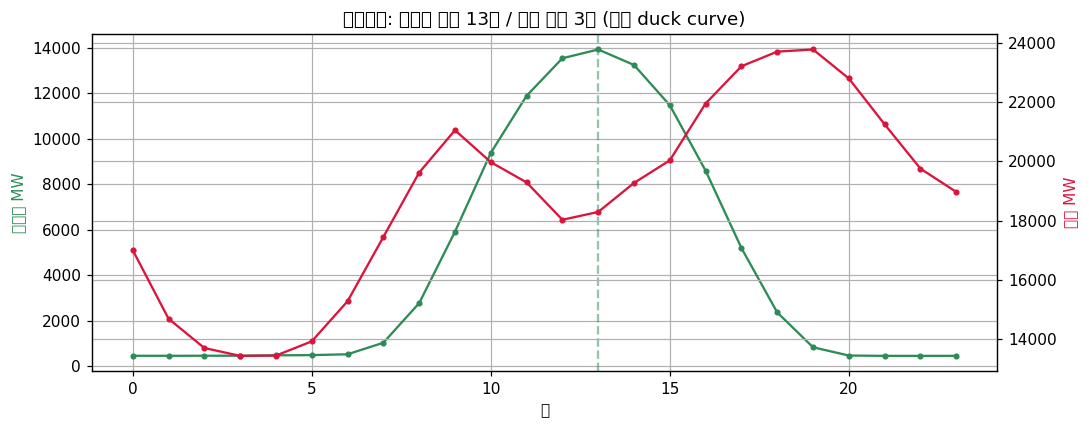

신재생 최대 13시, 가스 최소 3시


In [3]:
prof=d.groupby('hour').agg(renew=('true_renew','mean'),gas=('gen_gas_kr','mean'))
fig,ax=plt.subplots(figsize=(10,4)); ax2=ax.twinx()
ax.plot(prof.index,prof.renew,'-o',ms=3,color='seagreen',label='진짜 신재생')
ax2.plot(prof.index,prof.gas,'-o',ms=3,color='crimson',label='가스')
ax.set_xlabel('시'); ax.set_ylabel('신재생 MW',color='seagreen'); ax2.set_ylabel('가스 MW',color='crimson')
hr,hg=prof.renew.idxmax(),prof.gas.idxmin(); ax.axvline(hr,ls='--',color='seagreen',alpha=.5)
ax.set_title('시간대별: 신재생 최대 %d시 / 가스 최소 %d시 (한낮 duck curve)'%(hr,hg))
plt.tight_layout(); plt.savefig(FIG/'b2_hourly.png'); plt.show()
print('신재생 최대 %d시, 가스 최소 %d시'%(hr,hg))


**읽는 법**: 한낮 태양광 최대 시각과 가스 최소 시각이 겹치면, 한낮 신재생이 가스를 눌러내는 것.

## 3. 저수요(봄·가을) 세밀 비교

C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\1276270328.py:16: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b3_springfall_midday.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\1276270328.py:16: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b3_springfall_midday.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\1276270328.py:16: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b3_springfall_midday.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\1276270328.py:16: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(FIG/'b3_springfall_midday.png'); plt.show()
C:\Users\bjkim\AppData\Local\Temp\ipykernel_30324\1276270328.py:16: UserWarn

             계절    행수  신재생계수(전체)  신재생계수(한낮11-15)
 봄가을(3-5,9-11월) 19600     -0.388          -0.383
여름겨울(6-8,12-2월) 18919     -0.342          -0.363


C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48388 (\N{HANGUL SYLLABLE BOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bjkim\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

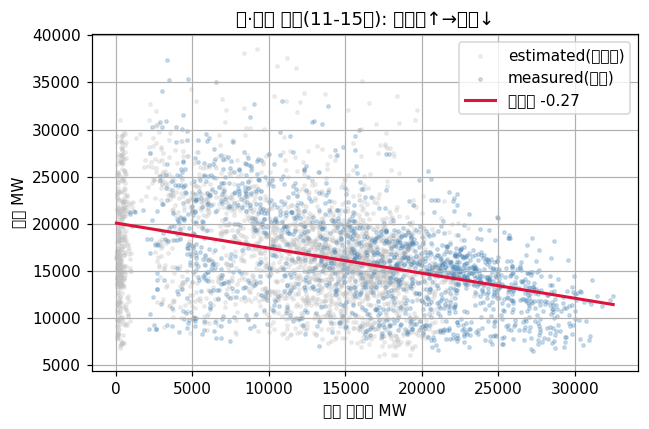

In [4]:
seas={'봄가을(3-5,9-11월)':[3,4,5,9,10,11],'여름겨울(6-8,12-2월)':[6,7,8,12,1,2]}
rows=[]
for lbl,ms in seas.items():
    s=d[d.month.isin(ms)]; mid=s[s.hour.between(11,15)]
    rows.append([lbl,len(s),round(coef(s,'true_demand','true_renew'),3),round(coef(mid,'true_demand','true_renew'),3)])
tab3=pd.DataFrame(rows,columns=['계절','행수','신재생계수(전체)','신재생계수(한낮11-15)'])
tab3.to_csv(TAB/'b3_season.csv',index=False); print(tab3.to_string(index=False))

sa=d[d.month.isin(seas['봄가을(3-5,9-11월)'])]; mid=sa[sa.hour.between(11,15)]
fig,ax=plt.subplots(figsize=(6,4))
for s,c in [('estimated(역추정)','silver'),('measured(실측)','steelblue')]:
    g=mid[mid.src==s]; ax.scatter(g.true_renew,g.gen_gas_kr,s=5,alpha=0.25,color=c,label=s)
b=np.polyfit(mid.true_renew,mid.gen_gas_kr,1); xs=np.linspace(mid.true_renew.min(),mid.true_renew.max(),50)
ax.plot(xs,np.polyval(b,xs),'crimson',lw=2,label='기울기 %.2f'%b[0])
ax.set_xlabel('진짜 신재생 MW'); ax.set_ylabel('가스 MW'); ax.set_title('봄·가을 한낮(11-15시): 신재생↑→가스↓'); ax.legend()
plt.tight_layout(); plt.savefig(FIG/'b3_springfall_midday.png'); plt.show()


**읽는 법**: 저수요(봄·가을)는 가스가 한계 발전원이라 신재생이 직접 밀어낸다. 한낮 계수가 음(−)이면 가설 성립.

## 4. 결론 — 전국이 제주와 비슷한가
- 복원 후 전국에서도 신재생↑→가스↓가 뚜렷(계수 ≈ −0.33). 저수요 한낮에서 특히 명확.
- 즉 전국도 (숨은 신재생까지 보면) **제주형 대체 패턴이 상존**. "저수요 한정"보다 강한 결론.
- 다만 전국 전체 평균으로는 여전히 수요 주도(가스 거의 항상 켜짐). 정직한 서술: "수요가 규모를 정하고, 신재생이 그 위에서 가스를 밀어낸다."


## 5. 데이터셋/모델 함의 (G-11)
- 역추정으로 **진짜 신재생/수요를 2020+ 전 구간 확보** → 7-A를 (true_demand, true_renew)로 재학습 가능(학습창 확장 옵션 c).
- 단 2024-11 이전은 역추정값 → 학습에 쓰면 **반드시 역추정 라벨/한계 명시**. 정확도 핵심 수치는 measured 구간으로도 별도 확인.
- 예측 성능 자체는 net_load/수요로 충분(R²0.78)했으나, 재학습의 가치는 **모델이 대체효과(신재생 음효과)를 명시적으로 담는 것**(발표 설득력).


In [5]:
import json
json.dump({'period':'2022+','rows':int(len(d)),
  'coef_grid':round(float(coef(d,'real_demand_land','renew_gen_total_kr')),3),
  'coef_true':round(float(coef(d,'true_demand','true_renew')),3),
  'coef_true_estimated':round(float(coef(d[d.src.str.startswith('estimated')],'true_demand','true_renew')),3),
  'coef_true_measured':round(float(coef(d[d.src.str.startswith('measured')],'true_demand','true_renew')),3)},
  open('btm_ppa_summary.json','w',encoding='utf-8'),ensure_ascii=False,indent=2)
print('saved btm_ppa_summary.json')


saved btm_ppa_summary.json
